# Phase 1 – Feature Engineering

**Ziel:** Rohdaten aus allen drei `.xlsx`-Dateien laden, PLZ auf Gebiete mappen,
Zeitfeatures ableiten, pro `(gebiet_id, date, hour)` aggregieren und als
`models/features_aggregated.pkl` speichern.

Regeln (AGENT.md):
- Keine DB-Verbindung
- Jeder Schritt wird mit einer Ausgabe verifiziert
- PLZ ohne Mapping → `gebiet_id = -1`, separat loggen, nicht verwerfen

In [1]:
# Abhängigkeiten importieren
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Projektwurzel zum Suchpfad hinzufügen, damit src/ gefunden wird
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features import (
    PLZ_TO_GEBIET, GEBIET_NAMES, FEATURE_COLUMNS,
    map_plz_to_gebiet
)

print('Imports OK')

Imports OK


## 1.1 – Daten laden & zusammenführen

In [2]:
# Alle xlsx-Dateien aus input/ laden und zusammenführen
INPUT_DIR = ROOT / 'input'
xlsx_files = sorted(INPUT_DIR.glob('*.xlsx'))
print(f'Gefundene Dateien: {[f.name for f in xlsx_files]}')

frames = []
for f in xlsx_files:
    # Sheet 'incidents' laden; falls nicht vorhanden, erstes Sheet nehmen
    try:
        df_part = pd.read_excel(f, sheet_name='incidents')
    except Exception:
        df_part = pd.read_excel(f, sheet_name=0)
    df_part['_source'] = f.name
    frames.append(df_part)
    print(f'  {f.name}: {df_part.shape}')

df = pd.concat(frames, ignore_index=True)
print(f'\nGesamt nach concat: {df.shape}')
df.head(3)

Gefundene Dateien: ['ems_mockdaten_lukas.xlsx', 'ems_mockdaten_merjem.xlsx', 'ems_mockdaten_mido.xlsx', 'ems_mockdaten_wetter.xlsx', 'ems_mockdaten_zusatz.xlsx']


  ems_mockdaten_lukas.xlsx: (4000, 8)
  ems_mockdaten_merjem.xlsx: (2795, 8)
  ems_mockdaten_mido.xlsx: (1000, 8)


  ems_mockdaten_wetter.xlsx: (21539, 8)


  ems_mockdaten_zusatz.xlsx: (9180, 8)

Gesamt nach concat: (38514, 10)


,date,time,PLZ,incident_type_(id),gender,age,location_type_(id),_source,incident_type_id,location_type_id
0,2025-01-01 00:00:00,08:52:00,4100,9.0,m,70,1.0,ems_mockdaten_lukas.xlsx,NaN,NaN
1,2025-01-01 00:00:00,12:48:00,4650,5.0,m,80,4.0,ems_mockdaten_lukas.xlsx,NaN,NaN
2,2025-01-01 00:00:00,17:31:00,4050,9.0,w,52,1.0,ems_mockdaten_lukas.xlsx,NaN,NaN


In [3]:
# Spaltennamen und Dtypes anzeigen
print(df.dtypes)
print('\nFehlende Werte:')
print(df.isnull().sum()[df.isnull().sum() > 0])

date                   object
time                   object
PLZ                     int64
incident_type_(id)    float64
gender                    str
age                     int64
location_type_(id)    float64
_source                   str
incident_type_id      float64
location_type_id      float64
dtype: object

Fehlende Werte:
incident_type_(id)     9180
location_type_(id)     9180
incident_type_id      29334
location_type_id      29334
dtype: int64


## 1.2 – PLZ → Gebiet-ID mappen

In [4]:
# PLZ-Spalte identifizieren (case-insensitive Suche)
plz_col = next(
    (c for c in df.columns if 'plz' in c.lower() or 'postleitzahl' in c.lower()),
    None
)
if plz_col is None:
    # Fallback: erste Spalte die numerisch und im PLZ-Bereich liegt
    for c in df.columns:
        try:
            vals = pd.to_numeric(df[c], errors='coerce').dropna()
            if vals.between(4000, 9999).mean() > 0.8:
                plz_col = c
                break
        except Exception:
            pass

print(f'PLZ-Spalte: {plz_col}')

# Mappen
df['gebiet_id'] = df[plz_col].apply(
    lambda x: map_plz_to_gebiet(x) if pd.notnull(x) else -1
)

n_unmapped = (df['gebiet_id'] == -1).sum()
print(f'\nNicht gemappte PLZ (gebiet_id == -1): {n_unmapped} Zeilen')

if n_unmapped > 0:
    print('\n--- Log nicht gemappter PLZ ---')
    print(df[df['gebiet_id'] == -1][[plz_col, '_source']].value_counts().to_string())

print('\nVerteilung gebiet_id:')
print(df['gebiet_id'].value_counts().sort_index())

PLZ-Spalte: PLZ

Nicht gemappte PLZ (gebiet_id == -1): 439 Zeilen

--- Log nicht gemappter PLZ ---
PLZ   _source                  
4601  ems_mockdaten_zusatz.xlsx    236
4130  ems_mockdaten_lukas.xlsx      16
4200  ems_mockdaten_lukas.xlsx      13
4901  ems_mockdaten_lukas.xlsx      13
4601  ems_mockdaten_lukas.xlsx      11
4604  ems_mockdaten_lukas.xlsx      10
4188  ems_mockdaten_lukas.xlsx       6
5302  ems_mockdaten_lukas.xlsx       6
4510  ems_mockdaten_lukas.xlsx       6
4231  ems_mockdaten_lukas.xlsx       6
5330  ems_mockdaten_lukas.xlsx       6
4045  ems_mockdaten_lukas.xlsx       6
4787  ems_mockdaten_lukas.xlsx       5
4380  ems_mockdaten_lukas.xlsx       5
4408  ems_mockdaten_lukas.xlsx       5
5283  ems_mockdaten_lukas.xlsx       5
4185  ems_mockdaten_lukas.xlsx       5
5342  ems_mockdaten_lukas.xlsx       5
4617  ems_mockdaten_lukas.xlsx       4
4803  ems_mockdaten_lukas.xlsx       4
4241  ems_mockdaten_lukas.xlsx       4
4244  ems_mockdaten_lukas.xlsx       4
4605  ems_m

## 1.3 – Datetime zusammenbauen & Zeitfeatures ableiten

In [5]:
# Datums- und Zeitspalten identifizieren
date_col = next((c for c in df.columns if 'date' in c.lower() or 'datum' in c.lower()), None)
time_col = next((c for c in df.columns if c.lower() in ('time', 'zeit', 'uhrzeit')), None)
dt_col   = next((c for c in df.columns if 'datetime' in c.lower() or 'timestamp' in c.lower()), None)

print(f'date_col={date_col}, time_col={time_col}, dt_col={dt_col}')

# datetime zusammenbauen
if dt_col:
    df['datetime'] = pd.to_datetime(df[dt_col], errors='coerce')
elif date_col and time_col:
    df['datetime'] = pd.to_datetime(
        df[date_col].astype(str) + ' ' + df[time_col].astype(str),
        errors='coerce'
    )
elif date_col:
    df['datetime'] = pd.to_datetime(df[date_col], errors='coerce')
else:
    raise ValueError('Keine Datums- oder Zeitspalte gefunden. Spalten: ' + str(df.columns.tolist()))

n_nat = df['datetime'].isna().sum()
print(f'NaT nach Parsing: {n_nat}')

# Zeitfeatures ableiten
df['hour']       = df['datetime'].dt.hour
df['weekday']    = df['datetime'].dt.dayofweek   # 0=Mo
df['month']      = df['datetime'].dt.month
df['quarter']    = df['datetime'].dt.quarter
df['is_weekend'] = (df['weekday'] >= 5).astype(int)
df['date']       = df['datetime'].dt.date

season_map = {12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3}
df['season'] = df['month'].map(season_map)

print('\nZeitfeatures Beispiel:')
df[['datetime','hour','weekday','month','quarter','is_weekend','season']].head(3)

date_col=date, time_col=time, dt_col=None


NaT nach Parsing: 0

Zeitfeatures Beispiel:


,datetime,hour,weekday,month,quarter,is_weekend,season
0,2025-01-01 08:52:00,8,2,1,1,0,0
1,2025-01-01 12:48:00,12,2,1,1,0,0
2,2025-01-01 17:31:00,17,2,1,1,0,0


## 1.4 – Aggregation: Einsätze pro (gebiet_id, date, hour)

In [6]:
# Nur gültige Zeilen (gebiet_id != -1, kein NaT) für Aggregation verwenden
df_valid = df[(df['gebiet_id'] != -1) & df['datetime'].notna()].copy()
print(f'Zeilen für Aggregation: {len(df_valid)} (von {len(df)} gesamt)')

# Aggregieren
agg_cols = ['gebiet_id', 'date', 'hour', 'weekday', 'month', 'quarter', 'is_weekend', 'season']
df_agg = (
    df_valid
    .groupby(agg_cols)
    .size()
    .reset_index(name='einsatz_count')
)

print(f'\nAggregiertes DataFrame: {df_agg.shape}')
print('\nStatistik einsatz_count:')
print(df_agg['einsatz_count'].describe())

df_agg.head()

Zeilen für Aggregation: 38075 (von 38514 gesamt)

Aggregiertes DataFrame: (33437, 9)

Statistik einsatz_count:
count    33437.000000
mean         1.138709
std          0.390424
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          5.000000
Name: einsatz_count, dtype: float64


,gebiet_id,date,hour,weekday,month,quarter,is_weekend,season,einsatz_count
0,1,2024-01-01,0,0,1,1,0,0,1
1,1,2024-01-01,2,0,1,1,0,0,1
2,1,2024-01-01,8,0,1,1,0,0,1
3,1,2024-01-02,10,1,1,1,0,0,1
4,1,2024-01-02,11,1,1,1,0,0,3


In [7]:
# Prüfen: gibt es Stunden mit 0 Einsätzen (fehlende Stunden im Zeitraster)?
# Fehlende Stunden entstehen, wenn keine Einsätze stattfanden – sie tauchen nicht im df auf.
total_combinations = df_agg['gebiet_id'].nunique() * df_agg['date'].nunique() * 24
present_combinations = len(df_agg)
missing_hours = total_combinations - present_combinations
print(f'Erwartete Kombinationen (Gebiete × Tage × 24h): {total_combinations}')
print(f'Vorhandene Kombinationen:                        {present_combinations}')
print(f'Fehlende Stunden (kein Einsatz):                 {missing_hours}')
print('\nHinweis: Fehlende Stunden = Stunden ohne Einsätze. Das Modell lernt nur aus aktiven Stunden.')

Erwartete Kombinationen (Gebiete × Tage × 24h): 263160
Vorhandene Kombinationen:                        33437
Fehlende Stunden (kein Einsatz):                 229723

Hinweis: Fehlende Stunden = Stunden ohne Einsätze. Das Modell lernt nur aus aktiven Stunden.


## 1.5 – Features finalisieren & als PKL speichern

In [8]:
import joblib

# Feature-Vektor und Zielvariable definieren
# FEATURE_COLUMNS = ['gebiet_id', 'hour', 'weekday', 'month', 'quarter', 'is_weekend', 'season']
TARGET = 'einsatz_count'

# 'date' wird zusätzlich zu FEATURE_COLUMNS mitgespeichert (nicht Teil des Modell-Feature-Vektors),
# damit Phase 5 (05_feature_engineering_v2) Feiertage/Events/Wetter exakt pro Kalendertag joinen kann.
df_model = df_agg[['date'] + FEATURE_COLUMNS + [TARGET]].copy()
print(f'Modell-DataFrame: {df_model.shape}')
print(df_model.dtypes)

# PKL speichern
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)
out_path = MODELS_DIR / 'features_aggregated.pkl'
joblib.dump(df_model, out_path)
print(f'\nGespeichert: {out_path} ({out_path.stat().st_size / 1024:.1f} KB)')

Modell-DataFrame: (33437, 9)
date             object
gebiet_id         int64
hour              int32
weekday           int32
month             int32
quarter           int32
is_weekend        int64
season            int64
einsatz_count     int64
dtype: object

Gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\models\features_aggregated.pkl (1733.3 KB)


## 1.6 – Validierungsplot: Einsätze pro Gebiet

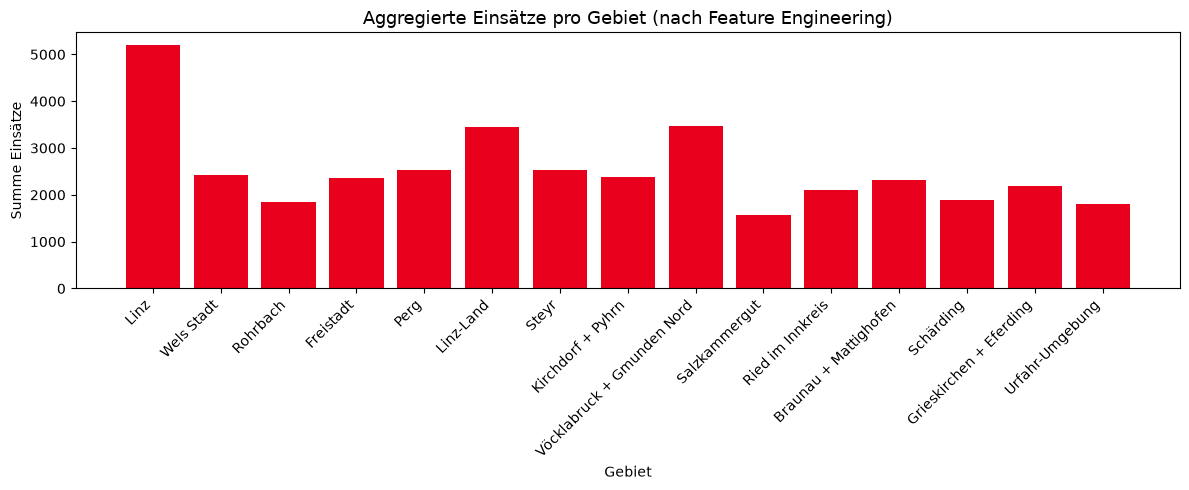

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\aggregation_check.png

Gesamtanzahl aggregierter Zeilen: 33437


In [9]:
# Einsätze pro Gebiet summieren und als Balkendiagramm speichern
einsaetze_per_gebiet = df_agg.groupby('gebiet_id')['einsatz_count'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    [GEBIET_NAMES.get(g, str(g)) for g in einsaetze_per_gebiet.index],
    einsaetze_per_gebiet.values,
    color='#E8001C'
)
ax.set_title('Aggregierte Einsätze pro Gebiet (nach Feature Engineering)', fontsize=13)
ax.set_xlabel('Gebiet')
ax.set_ylabel('Summe Einsätze')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

OUTPUT_DIR = ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)
plot_path = OUTPUT_DIR / 'aggregation_check.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')
print(f'\nGesamtanzahl aggregierter Zeilen: {len(df_agg)}')

---
## ✅ Phase 1 abgeschlossen
- `models/features_aggregated.pkl` existiert
- Alle PLZ gemappt oder als `gebiet_id=-1` geloggt
- Aggregationsplot unter `output/aggregation_check.png`